# Exploratory Data Analysis on the KDD dataset

## Install and import libraries

In [1]:
%pip install --upgrade pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 17.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
Note: you may need to restart the kernel to use updated packages.


## Dataset Overview

In [33]:
df = pd.read_csv('../data/KDDTrain+.txt', header=None)

# The dataset does not contain the column names, so they need to be specified manually 
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
"root_shell","su_attempted","num_root","num_file_creations","num_shells",
"num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
"count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
"srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
"dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
"dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate",
"dst_host_srv_rerror_rate","attack","difficulty"
]

df.columns = columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print('Numerical columns:', list(num_cols))

cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns
print('Categorical columns:', list(cat_cols))

df.head()

# Check the datatypes and search for null values
# df.info()
# df.isnull().sum()

Numerical columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty']
Categorical columns: ['protocol_type', 'service', 'flag', 'attack']


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## Attack Distribution

The attack type can be `normal`, which means no attack, or other values based on the type of the attack.

In this project, the classification will be binary, so all attacks will be marked as `is_attack`.

Attacks percentage:  46.54%


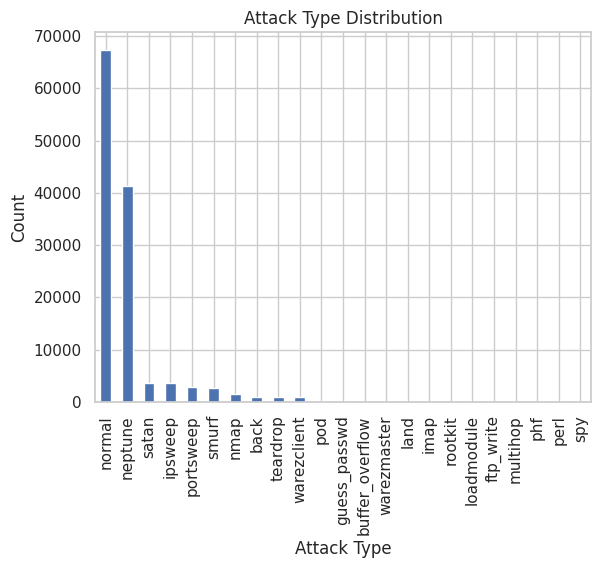

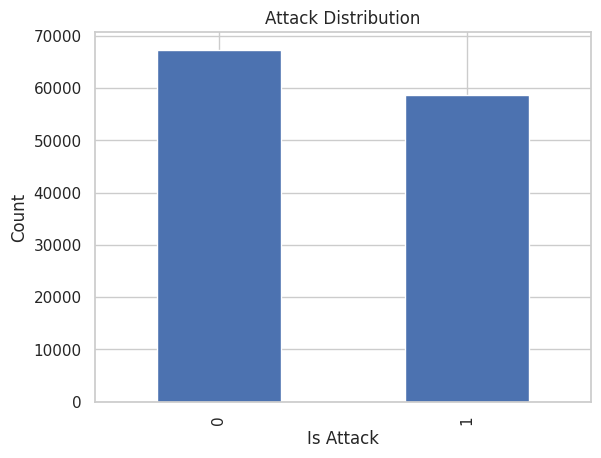

In [34]:
df['is_attack'] = df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
num_attacks = (df['is_attack'] == 1).sum()
print(f'Attacks percentage: {num_attacks / df.shape[0] * 100 : 0.2f}%')

plt.figure()
df['attack'].value_counts().plot(kind='bar')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.title('Attack Type Distribution')
plt.show()

plt.figure()
df['is_attack'].value_counts().plot(kind='bar')
plt.xlabel('Is Attack')
plt.ylabel('Count')
plt.title('Attack Distribution')
plt.show()

## Categorical Feature Analysis

Some important categorical features are:
- protocol_type
- service
- flag

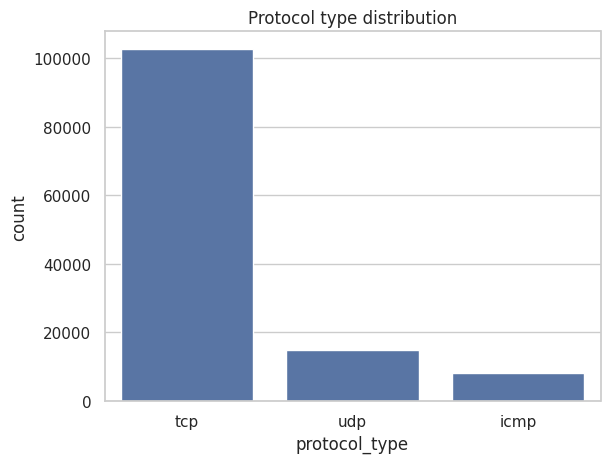

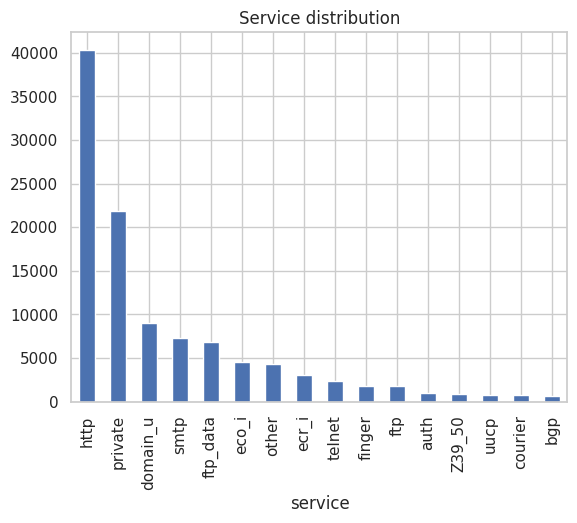

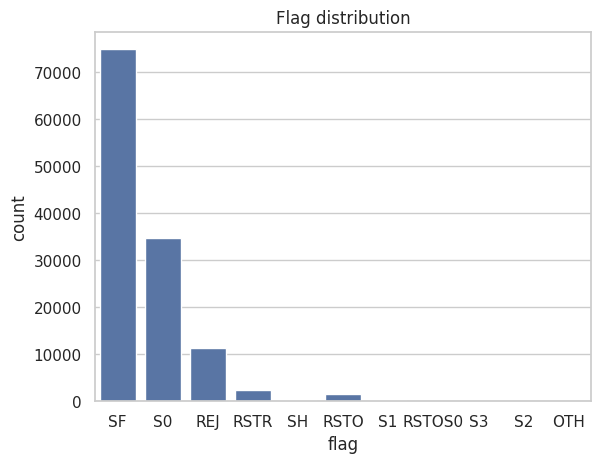

In [35]:
sns.countplot(x='protocol_type', data=df)
plt.title('Protocol type distribution')
plt.show()

# Only plot the most common services so that the graph is readable
service_counts = df['service'].value_counts()
major_services = service_counts[service_counts >= 700]

major_services.plot(kind='bar')
plt.title('Service distribution')
plt.show()

sns.countplot(x='flag', data=df)
plt.title('Flag distribution')
plt.show()

## Numerical Feature Analysis

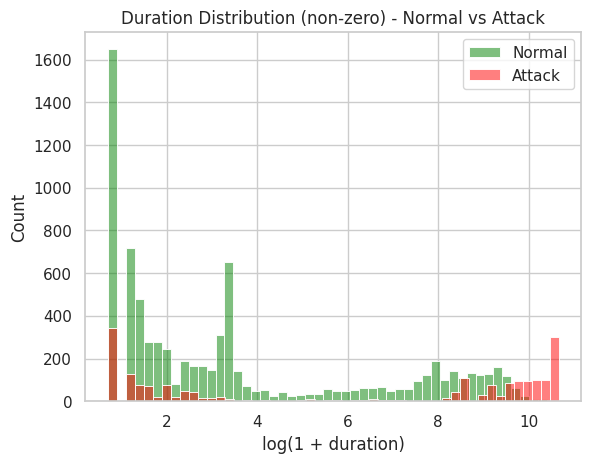

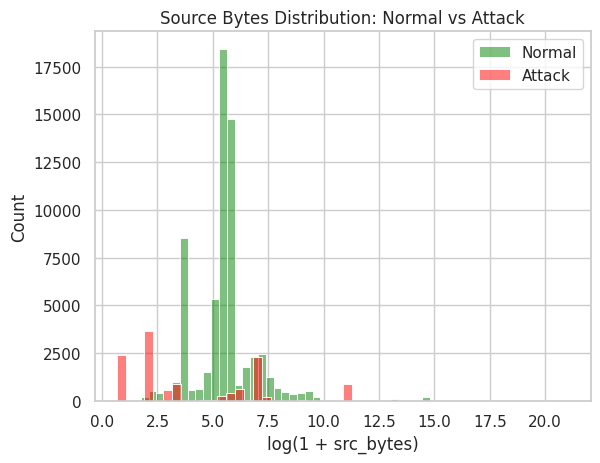

In [36]:
# Filter duration > 0
duration_df = df[df['duration'] > 0]

sns.histplot(np.log1p(duration_df[duration_df['is_attack'] == 0]['duration']),
             bins=50, color='green', label='Normal', alpha=0.5)
sns.histplot(np.log1p(duration_df[duration_df['is_attack'] == 1]['duration']),
             bins=50, color='red', label='Attack', alpha=0.5)
plt.xlabel('log(1 + duration)')
plt.title('Duration Distribution (non-zero) - Normal vs Attack')
plt.legend()
plt.show()

# Filter src_bytes > 0
bytes_df = df[df['src_bytes'] > 0]

sns.histplot(np.log1p(bytes_df[bytes_df['is_attack'] == 0]['src_bytes']), bins=50, color='green', label='Normal', alpha=0.5)
sns.histplot(np.log1p(bytes_df[bytes_df['is_attack'] == 1]['src_bytes']), bins=50, color='red', label='Attack', alpha=0.5)
plt.xlabel('log(1 + src_bytes)')
plt.title('Source Bytes Distribution: Normal vs Attack')
plt.legend()
plt.show()


## Correlation Analysis

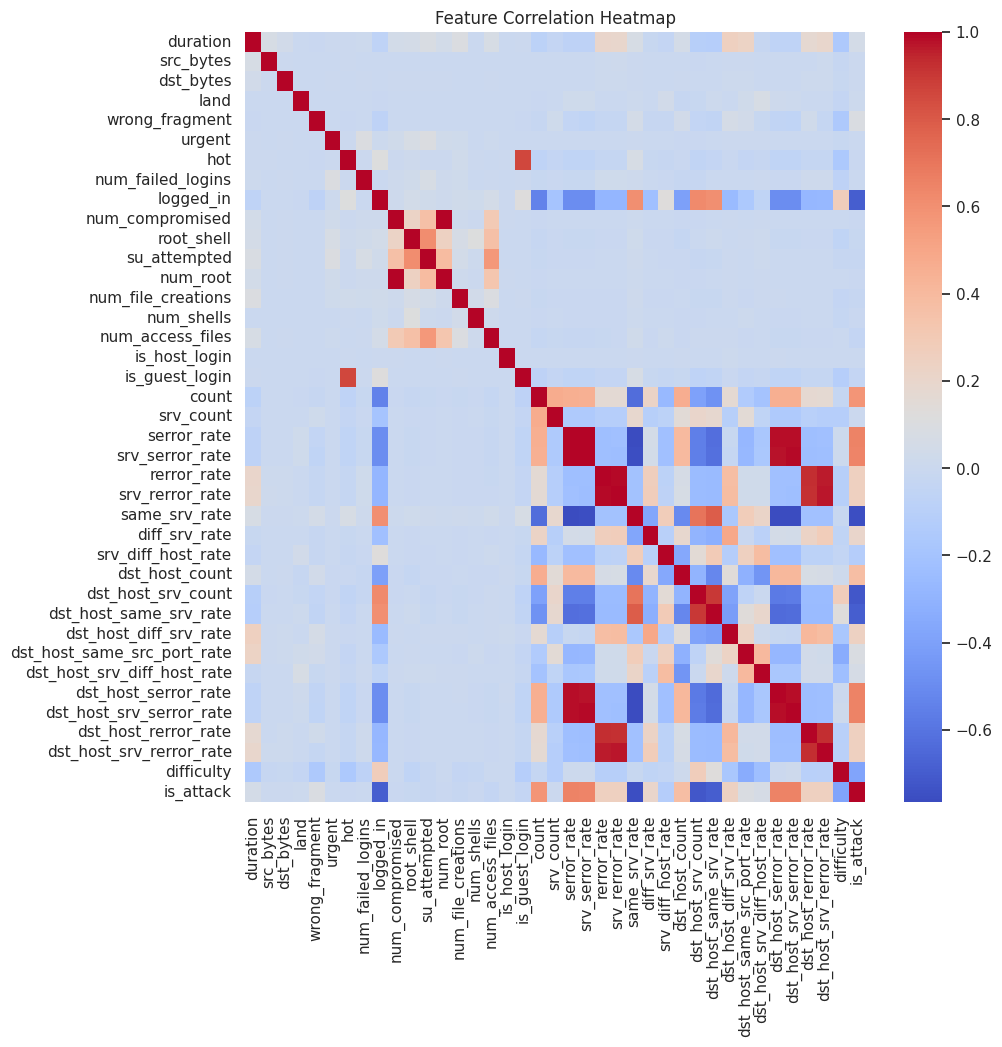

In [37]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['num_outbound_cmds'])
corr = numeric_df.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Key Observations

1. **Attack frequency**: about **46%** of the connections are attacks, most of them being **Neptune attacks**, a denial-of-service type of attack

2. **Categorical features**:
- **Protocol**: most connections use `tcp`
- **Service**: `http` and `private` are the most common
- **Flags**: `SF` and `S0` are the most frequent

3. **Numerical features**:
- **Connection duration**: Attacks tend to have shorter durations, often zero
- **Payload**: Attacks don't consistently have smaller payloads
- Many features are skewed, so **log transformations or scaling** may help models:

4. **Implications for ML**:
- Need to **encode** categorical features
- Target variable should be simplified to **binary: normal(0) or attack(1)**